# Submission Pertama: Menyelesaikan Permasalahan Human Resources

**Nama:** Angga Yulian Adi Pradana  
**Email:** anggayulian2004@gmail.com  
**Id Dicoding:** anggapradanaa

---


## Business Understanding

### Problem Statement
Perusahaan mengalami **attrition rate > 10%** yang menyebabkan:
- Biaya rekrutmen & pelatihan yang tinggi
- Hilangnya pengetahuan institusional
- Penurunan produktivitas tim

### Objective
1. **Identifikasi** faktor-faktor utama penyebab attrition karyawan
2. **Bangun model prediksi** attrition berbasis Machine Learning (XGBoost)
3. **Evaluasi** performa model dengan metrik yang sesuai untuk HR

### Success Metrics
- Ditemukan minimal 5 faktor utama penyebab attrition
- Model memiliki **ROC-AUC ≥ 0.80**
- **Recall ≥ 0.70** (agar HR tidak melewatkan karyawan berisiko)


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
import joblib

# Plot style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('Set2')

print("Libraries loaded successfully")
print(f"pandas  : {pd.__version__}")
print(f"sklearn : {__import__('sklearn').__version__}")


Libraries loaded successfully
pandas  : 1.5.3
sklearn : 1.7.2


## Data Understanding

In [2]:
# Load dataset
df = pd.read_csv('data/employee_data.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum():,} total")
print(f"Attrition NaN  : {df['Attrition'].isna().sum():,} rows")
print()
print(df.dtypes)


DATASET OVERVIEW
Shape          : 1,470 rows × 35 columns
Missing values : 412 total
Attrition NaN  : 412 rows

EmployeeId                    int64
Age                           int64
Attrition                   float64
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeCount                 int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                       object
OverTime                     object
PercentSalaryHike             int64
PerformanceRating       

In [3]:
# Missing value analysis
missing = df.isnull().sum()
missing = missing[missing > 0]
print("=" * 40)
print("MISSING VALUES")
print("=" * 40)
for col, cnt in missing.items():
    pct = cnt / len(df) * 100
    print(f"  {col:<25} {cnt:>4} rows ({pct:.1f}%)")

print()
# Attrition distribution (non-null only)
attr = df['Attrition'].dropna()
print("Attrition Distribution (non-missing):")
print(f"No  (0): {int((attr==0).sum()):>4}  ({(attr==0).mean()*100:.1f}%)")
print(f"Yes (1): {int((attr==1).sum()):>4}  ({(attr==1).mean()*100:.1f}%)")
print(f"Attrition Rate: {attr.mean()*100:.1f}%")


MISSING VALUES
  Attrition                  412 rows (28.0%)

Attrition Distribution (non-missing):
No  (0):  879  (83.1%)
Yes (1):  179  (16.9%)
Attrition Rate: 16.9%


In [4]:
# Descriptive statistics for key columns
key_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
            'DistanceFromHome', 'JobSatisfaction', 'WorkLifeBalance']
df[key_cols].describe().round(2)


,Age,MonthlyIncome,YearsAtCompany,TotalWorkingYears,DistanceFromHome,JobSatisfaction,WorkLifeBalance
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,6502.93,7.01,11.28,9.19,2.73,2.76
std,9.14,4707.96,6.13,7.78,8.11,1.10,0.71
min,18.00,1009.00,0.00,0.00,1.00,1.00,1.00
25%,30.00,2911.00,3.00,6.00,2.00,2.00,2.00
50%,36.00,4919.00,5.00,10.00,7.00,3.00,3.00
75%,43.00,8379.00,9.00,15.00,14.00,4.00,3.00
max,60.00,19999.00,40.00,40.00,29.00,4.00,4.00


## Data Preparation

Langkah-langkah:
1. Drop baris dengan Attrition NaN (tidak ada label → tidak bisa dilatih)
2. Drop kolom konstan (EmployeeCount, StandardHours, Over18, EmployeeId)
3. Encode variabel kategorikal
4. Split train-test (80:20, stratified)

In [5]:
# Step 3.1 — Drop baris di mana Attrition mengandung missing value
df_model = df.dropna(subset=['Attrition']).copy()
df_model['Attrition'] = df_model['Attrition'].astype(int)
print(f"Data untuk modeling: {df_model.shape[0]:,} rows (setelah drop {df['Attrition'].isna().sum()} NaN)")

# Step 3.2 — Drop kolom konstan / tidak informatif
drop_cols = ['EmployeeId', 'EmployeeCount', 'StandardHours', 'Over18']
df_model.drop(columns=drop_cols, inplace=True)
print(f"Kolom tersisa: {df_model.shape[1]} (setelah drop {len(drop_cols)} kolom konstan)")


Data untuk modeling: 1,058 rows (setelah drop 412 NaN)
Kolom tersisa: 31 (setelah drop 4 kolom konstan)


In [6]:
# Step 3.3 — Encoding
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal: {cat_cols}")

le = LabelEncoder()
label_maps = {}
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    label_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("\nEncoding selesai")
print("Contoh mapping OverTime:", label_maps.get('OverTime', {}))


Kolom kategorikal: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Encoding selesai
Contoh mapping OverTime: {'No': 0, 'Yes': 1}


In [7]:
# Step 3.4 — Feature & Target split
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

# Step 3.5 — Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Split selesai:")
print(f"Train : {X_train.shape[0]:,} rows | Attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,} rows | Attrition rate: {y_test.mean()*100:.1f}%")


Split selesai:
Train : 846 rows | Attrition rate: 16.9%
Test  : 212 rows | Attrition rate: 17.0%


## Exploratory Data Analysis (EDA)


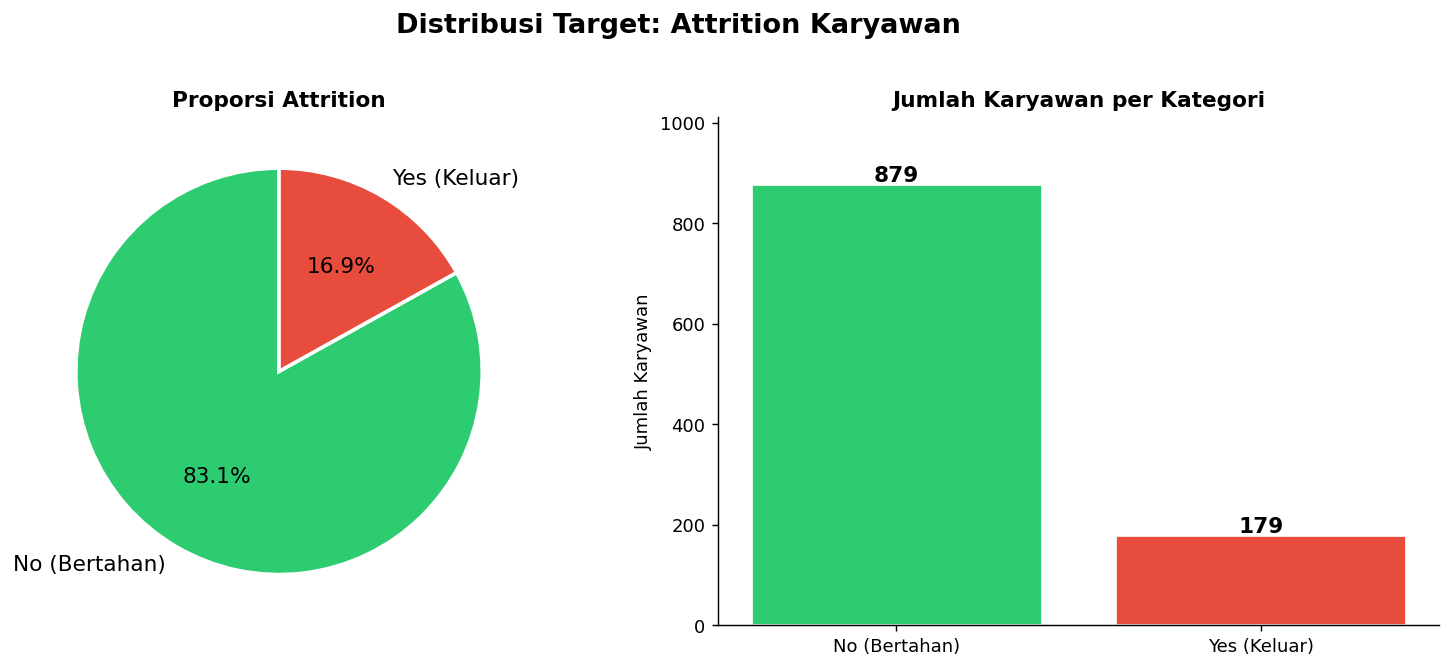


Attrition Rate: 16.9%
Insight: Dataset mengalami class imbalance — kelas Yes jauh lebih sedikit


In [8]:
# ── EDA 1: Distribusi Target (Attrition) ──────────────────────
df_eda = df.dropna(subset=['Attrition']).copy()
df_eda['Attrition'] = df_eda['Attrition'].astype(int)
df_eda['Attrition_Label'] = df_eda['Attrition'].map({0: 'No (Bertahan)', 1: 'Yes (Keluar)'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Target: Attrition Karyawan', fontsize=15, fontweight='bold', y=1.02)

# Pie chart
counts = df_eda['Attrition_Label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporsi Attrition', fontweight='bold')

# Bar chart
bars = axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Jumlah Karyawan per Kategori', fontweight='bold')
axes[1].set_ylabel('Jumlah Karyawan')
axes[1].set_ylim(0, max(counts.values) * 1.15)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print(f"\nAttrition Rate: {df_eda['Attrition'].mean()*100:.1f}%")
print("Insight: Dataset mengalami class imbalance — kelas Yes jauh lebih sedikit")


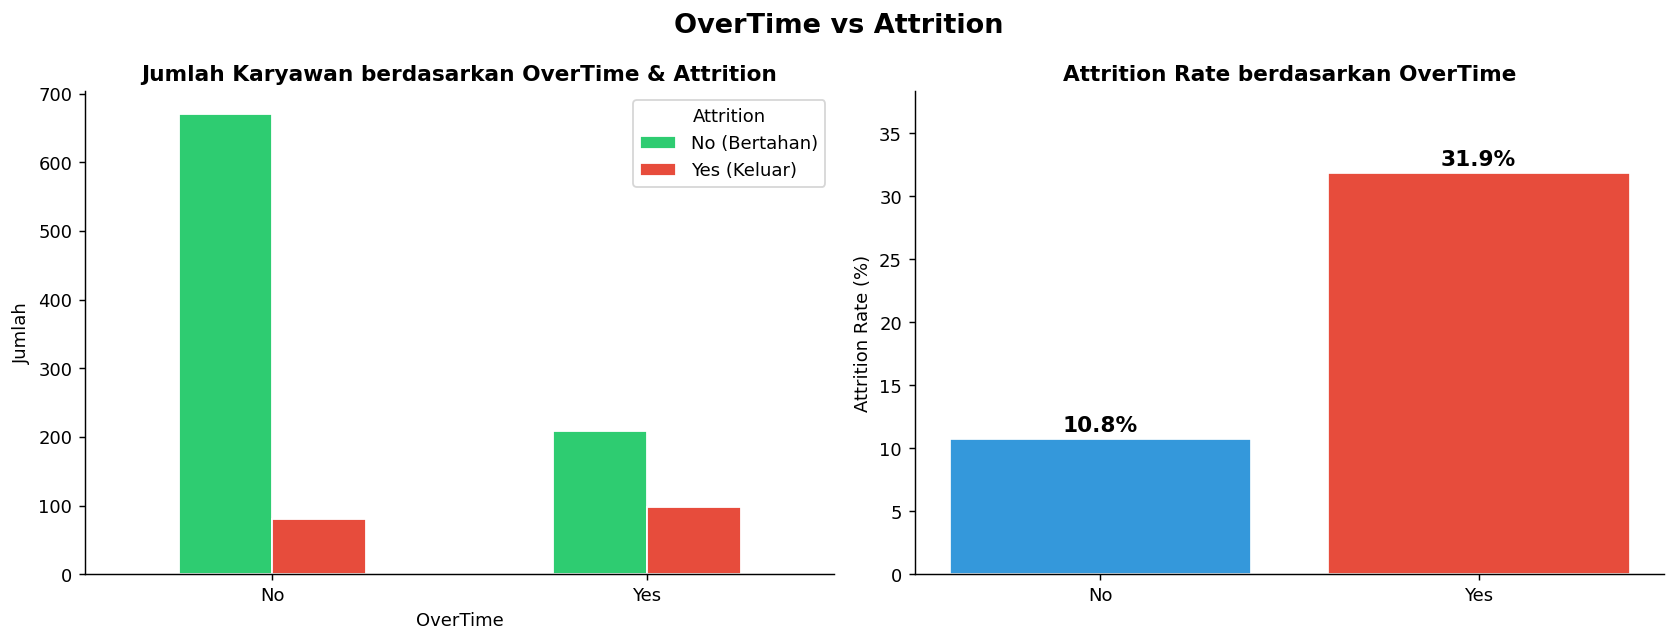


Insight Kunci:
   OverTime=No: Attrition Rate = 10.8%
   OverTime=Yes: Attrition Rate = 31.9%
   → Karyawan dengan OverTime memiliki attrition rate 3.0x lebih tinggi!


In [9]:
# ── EDA 2: OverTime vs Attrition ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('OverTime vs Attrition', fontsize=15, fontweight='bold')

# Count plot
ct = pd.crosstab(df_eda['OverTime'], df_eda['Attrition_Label'])
ct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
        edgecolor='white', linewidth=1)
axes[0].set_title('Jumlah Karyawan berdasarkan OverTime & Attrition', fontweight='bold')
axes[0].set_xlabel('OverTime')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Attrition')
sns.despine(ax=axes[0])

# Attrition rate per OverTime
rate = df_eda.groupby('OverTime')['Attrition'].mean() * 100
bars = axes[1].bar(rate.index, rate.values,
                   color=['#3498db' if x == 'No' else '#e74c3c' for x in rate.index],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Attrition Rate berdasarkan OverTime', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(rate.values) * 1.2)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print("\nInsight Kunci:")
for ot, r in rate.items():
    print(f"   OverTime={ot}: Attrition Rate = {r:.1f}%")
print(f"   → Karyawan dengan OverTime memiliki attrition rate {rate['Yes']/rate['No']:.1f}x lebih tinggi!")


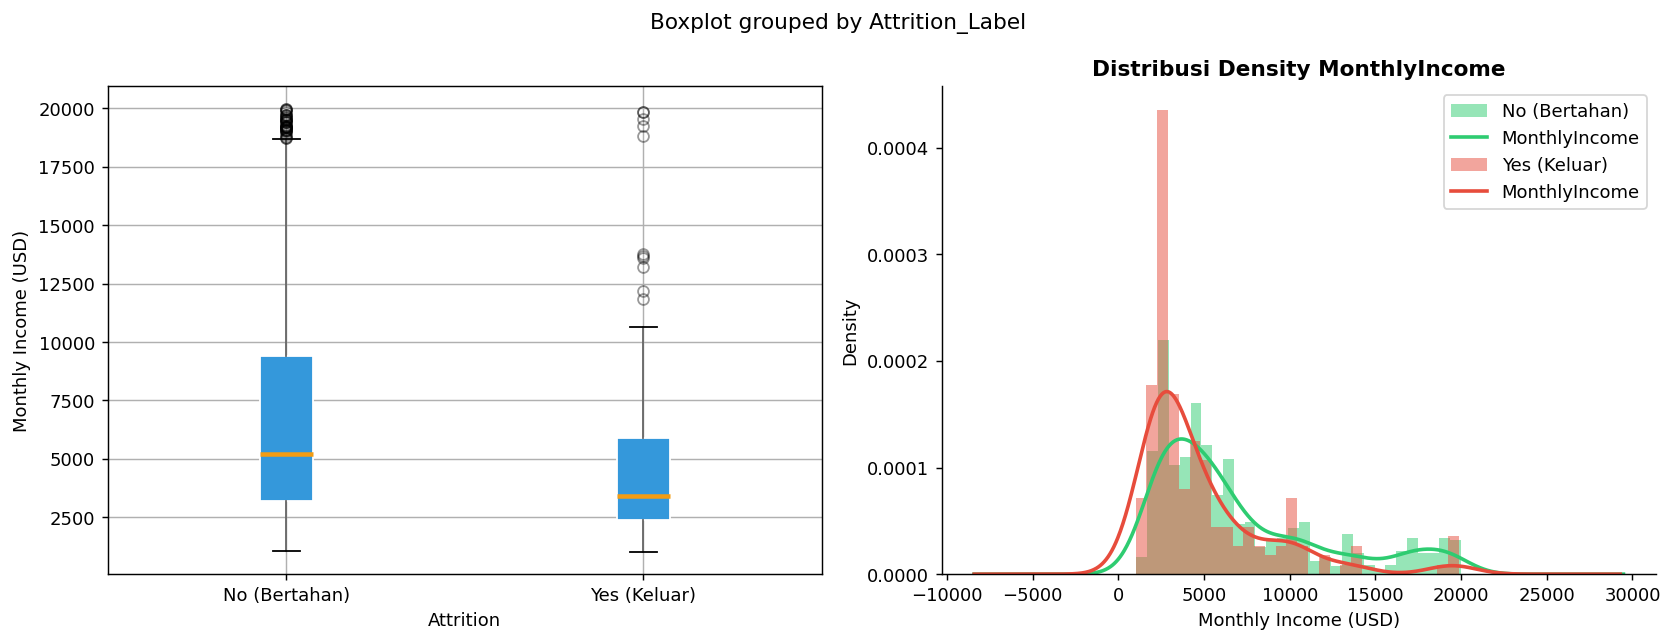


Insight Kunci:
Median Income (Bertahan) : $5,210
Median Income (Keluar)   : $3,388
→ Karyawan yang keluar memiliki median income $1,822 lebih rendah


In [10]:
# ── EDA 3: Monthly Income vs Attrition ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Monthly Income vs Attrition', fontsize=15, fontweight='bold')

# Boxplot
df_eda.boxplot(column='MonthlyIncome', by='Attrition_Label', ax=axes[0],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', color='white'),
               medianprops=dict(color='#f39c12', linewidth=2.5),
               flierprops=dict(marker='o', color='gray', alpha=0.4))
axes[0].set_title('Distribusi MonthlyIncome per Attrition', fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income (USD)')
plt.sca(axes[0])
plt.title('')

# KDE plot
for label, color in [('No (Bertahan)', '#2ecc71'), ('Yes (Keluar)', '#e74c3c')]:
    subset = df_eda[df_eda['Attrition_Label'] == label]['MonthlyIncome']
    axes[1].hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    subset.plot.kde(ax=axes[1], color=color, linewidth=2)
axes[1].set_title('Distribusi Density MonthlyIncome', fontweight='bold')
axes[1].set_xlabel('Monthly Income (USD)')
axes[1].set_ylabel('Density')
axes[1].legend()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

median_stay = df_eda[df_eda['Attrition']==0]['MonthlyIncome'].median()
median_leave = df_eda[df_eda['Attrition']==1]['MonthlyIncome'].median()
print(f"\nInsight Kunci:")
print(f"Median Income (Bertahan) : ${median_stay:,.0f}")
print(f"Median Income (Keluar)   : ${median_leave:,.0f}")
print(f"→ Karyawan yang keluar memiliki median income ${median_stay-median_leave:,.0f} lebih rendah")


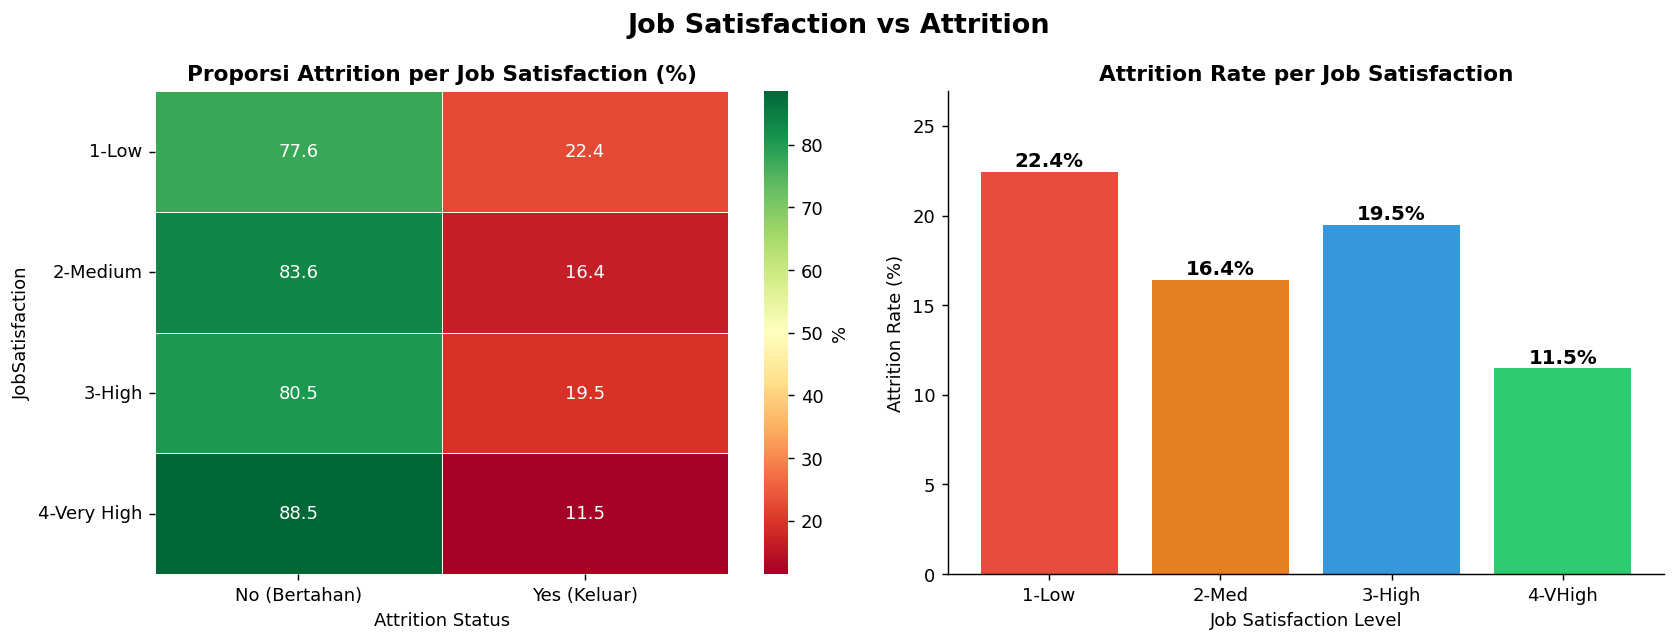


Insight Kunci:
JobSatisfaction=1: Attrition Rate = 22.4%
JobSatisfaction=2: Attrition Rate = 16.4%
JobSatisfaction=3: Attrition Rate = 19.5%
JobSatisfaction=4: Attrition Rate = 11.5%


In [11]:
# ── EDA 4: Job Satisfaction vs Attrition ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Job Satisfaction vs Attrition', fontsize=15, fontweight='bold')

# Heatmap proportion
ct = pd.crosstab(df_eda['JobSatisfaction'], df_eda['Attrition_Label'], normalize='index') * 100
sns.heatmap(ct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[0].set_title('Proporsi Attrition per Job Satisfaction (%)', fontweight='bold')
axes[0].set_xlabel('Attrition Status')
js_labels = {1: '1-Low', 2: '2-Medium', 3: '3-High', 4: '4-Very High'}
axes[0].set_yticklabels([js_labels.get(int(t.get_text()), t.get_text()) for t in axes[0].get_yticklabels()], rotation=0)

# Attrition rate per satisfaction level
rate = df_eda.groupby('JobSatisfaction')['Attrition'].mean() * 100
bars = axes[1].bar(rate.index.map({1: '1-Low', 2: '2-Med', 3: '3-High', 4: '4-VHigh'}),
                   rate.values,
                   color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'])
for bar, val in zip(bars, rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Attrition Rate per Job Satisfaction', fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Level')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(rate.values) * 1.2)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print("\nInsight Kunci:")
for level, r in rate.items():
    print(f"JobSatisfaction={level}: Attrition Rate = {r:.1f}%")


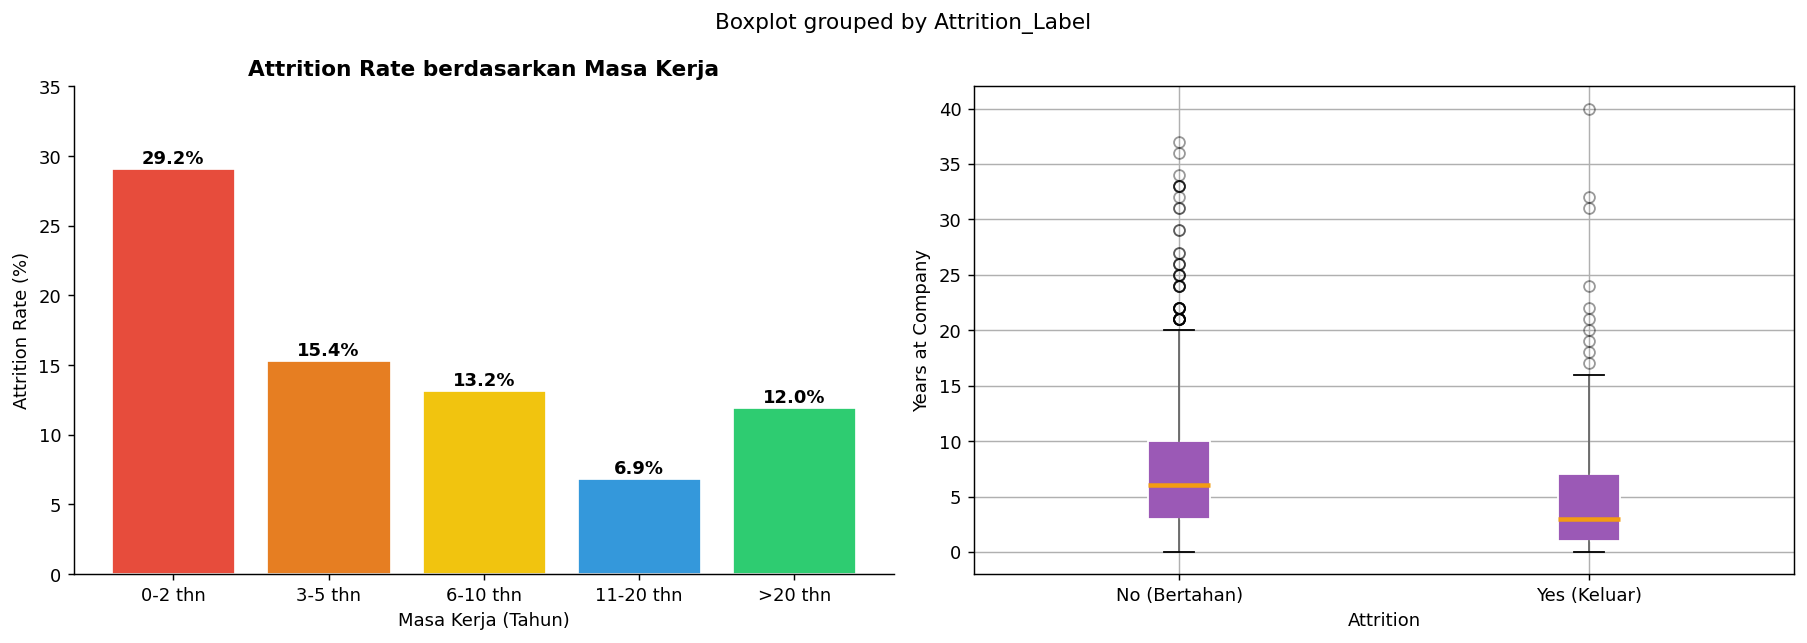


Insight Kunci:
Masa Kerja 0-2 thn: Attrition Rate = 29.2%
Masa Kerja 3-5 thn: Attrition Rate = 15.4%
Masa Kerja 6-10 thn: Attrition Rate = 13.2%
Masa Kerja 11-20 thn: Attrition Rate = 6.9%
Masa Kerja >20 thn: Attrition Rate = 12.0%
→ Karyawan baru (0-2 tahun) memiliki risiko attrition tertinggi


In [12]:
# ── EDA 5: Years at Company vs Attrition ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Years at Company vs Attrition', fontsize=15, fontweight='bold')

# Binned analysis
bins = [0, 2, 5, 10, 20, 40]
labels = ['0-2 thn', '3-5 thn', '6-10 thn', '11-20 thn', '>20 thn']
df_eda['TenureBin'] = pd.cut(df_eda['YearsAtCompany'], bins=bins, labels=labels, right=True)

rate_tenure = df_eda.groupby('TenureBin', observed=True)['Attrition'].mean() * 100
colors_t = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71']
bars = axes[0].bar(rate_tenure.index, rate_tenure.values, color=colors_t, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, rate_tenure.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Attrition Rate berdasarkan Masa Kerja', fontweight='bold')
axes[0].set_xlabel('Masa Kerja (Tahun)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, max(rate_tenure.values) * 1.2)
sns.despine(ax=axes[0])

# Box plot
df_eda.boxplot(column='YearsAtCompany', by='Attrition_Label', ax=axes[1],
               patch_artist=True,
               boxprops=dict(facecolor='#9b59b6', color='white'),
               medianprops=dict(color='#f39c12', linewidth=2.5),
               flierprops=dict(marker='o', color='gray', alpha=0.4))
axes[1].set_title('Distribusi Masa Kerja per Attrition', fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Years at Company')
plt.sca(axes[1])
plt.title('')

plt.tight_layout()
plt.show()

print("\nInsight Kunci:")
for tenure, rate in rate_tenure.items():
    print(f"Masa Kerja {tenure}: Attrition Rate = {rate:.1f}%")
print("→ Karyawan baru (0-2 tahun) memiliki risiko attrition tertinggi")


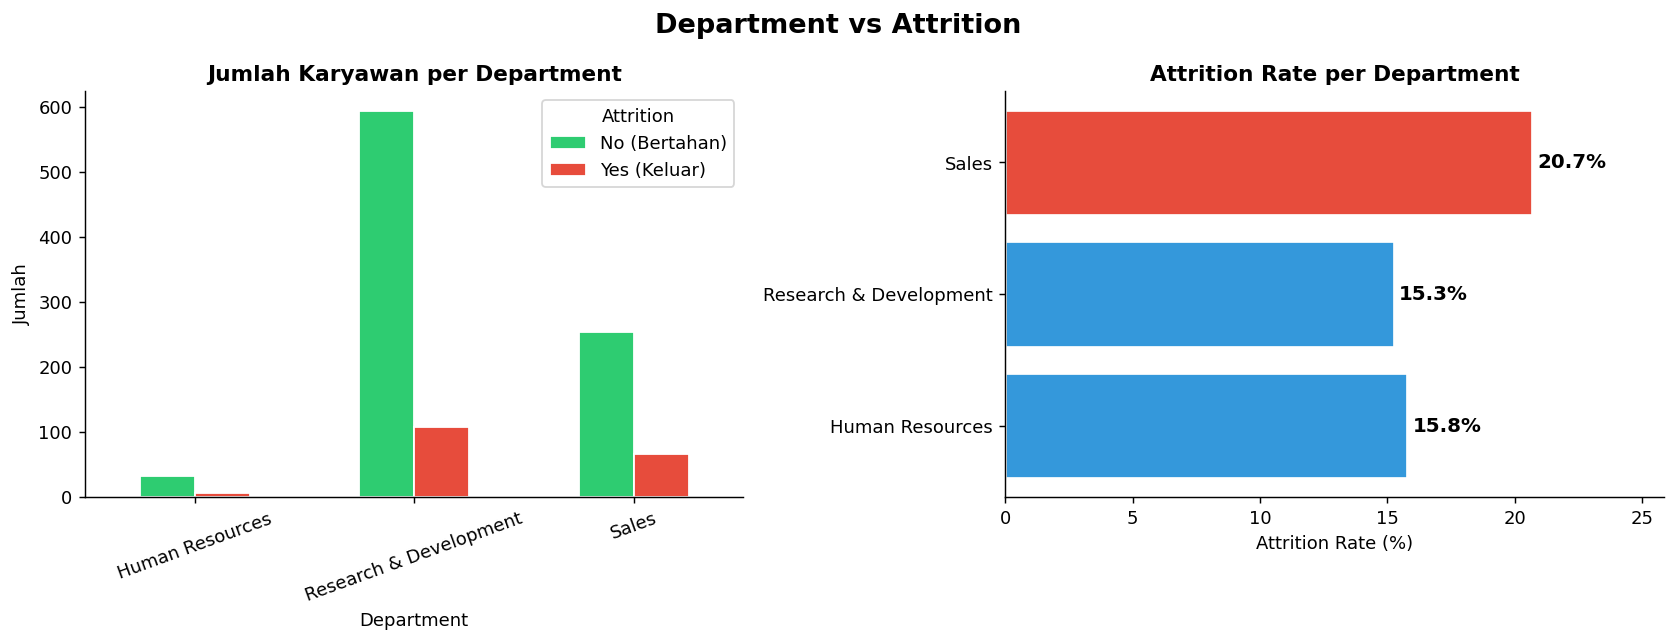


Insight Kunci:
Human Resources: Attrition Rate = 15.8%
Research & Development: Attrition Rate = 15.3%
Sales: Attrition Rate = 20.7%


In [13]:
# ── EDA 6: Department vs Attrition ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Department vs Attrition', fontsize=15, fontweight='bold')

dept_rate = df_eda.groupby('Department')['Attrition'].mean() * 100
dept_count = df_eda.groupby(['Department', 'Attrition_Label']).size().unstack(fill_value=0)

dept_count.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', linewidth=1)
axes[0].set_title('Jumlah Karyawan per Department', fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Attrition')
sns.despine(ax=axes[0])

colors_d = ['#e74c3c' if r == dept_rate.max() else '#3498db' for r in dept_rate.values]
bars = axes[1].barh(dept_rate.index, dept_rate.values, color=colors_d, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, dept_rate.values):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)
axes[1].set_title('Attrition Rate per Department', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_xlim(0, max(dept_rate.values) * 1.25)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print("\nInsight Kunci:")
for dept, r in dept_rate.items():
    print(f"{dept}: Attrition Rate = {r:.1f}%")


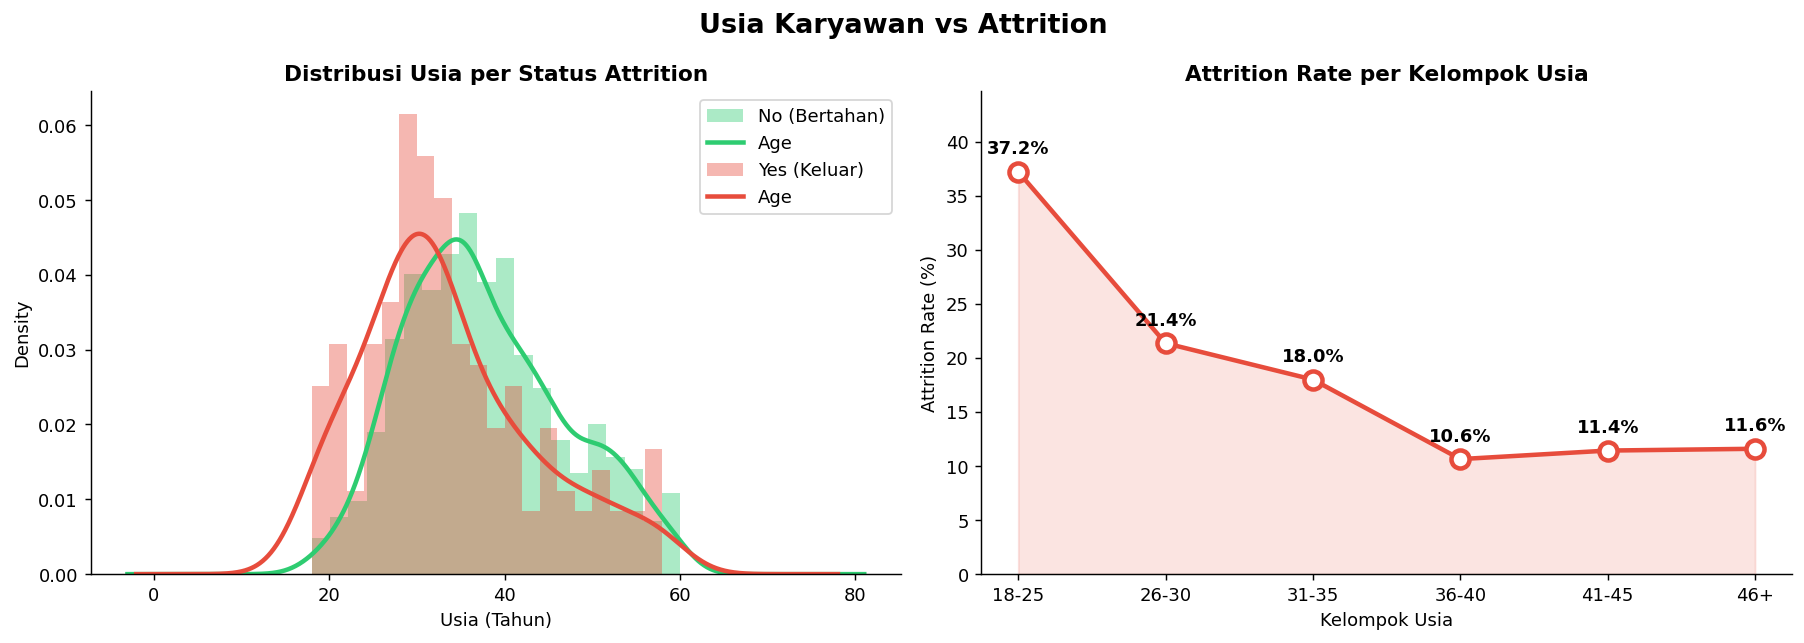


Insight Kunci:
Kelompok usia dengan attrition tertinggi: 18-25 (37.2%)
Kelompok usia dengan attrition terendah: 36-40 (10.6%)


In [14]:
# ── EDA 7: Usia vs Attrition ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Usia Karyawan vs Attrition', fontsize=15, fontweight='bold')

# KDE by group
for label, color in [('No (Bertahan)', '#2ecc71'), ('Yes (Keluar)', '#e74c3c')]:
    subset = df_eda[df_eda['Attrition_Label'] == label]['Age']
    axes[0].hist(subset, bins=20, alpha=0.4, color=color, density=True, label=label)
    subset.plot.kde(ax=axes[0], color=color, linewidth=2.5)
axes[0].set_title('Distribusi Usia per Status Attrition', fontweight='bold')
axes[0].set_xlabel('Usia (Tahun)')
axes[0].set_ylabel('Density')
axes[0].legend()
sns.despine(ax=axes[0])

# Binned age
age_bins = [18, 25, 30, 35, 40, 45, 61]
age_labels = ['18-25', '26-30', '31-35', '36-40', '41-45', '46+']
df_eda['AgeBin'] = pd.cut(df_eda['Age'], bins=age_bins, labels=age_labels, right=True)
rate_age = df_eda.groupby('AgeBin', observed=True)['Attrition'].mean() * 100
axes[1].plot(rate_age.index, rate_age.values, 'o-', color='#e74c3c',
             linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2.5)
for x, y in enumerate(rate_age.values):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Attrition Rate per Kelompok Usia', fontweight='bold')
axes[1].set_xlabel('Kelompok Usia')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(rate_age.values) * 1.2)
axes[1].fill_between(range(len(rate_age)), rate_age.values, alpha=0.15, color='#e74c3c')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print("\nInsight Kunci:")
print(f"Kelompok usia dengan attrition tertinggi: {rate_age.idxmax()} ({rate_age.max():.1f}%)")
print(f"Kelompok usia dengan attrition terendah: {rate_age.idxmin()} ({rate_age.min():.1f}%)")


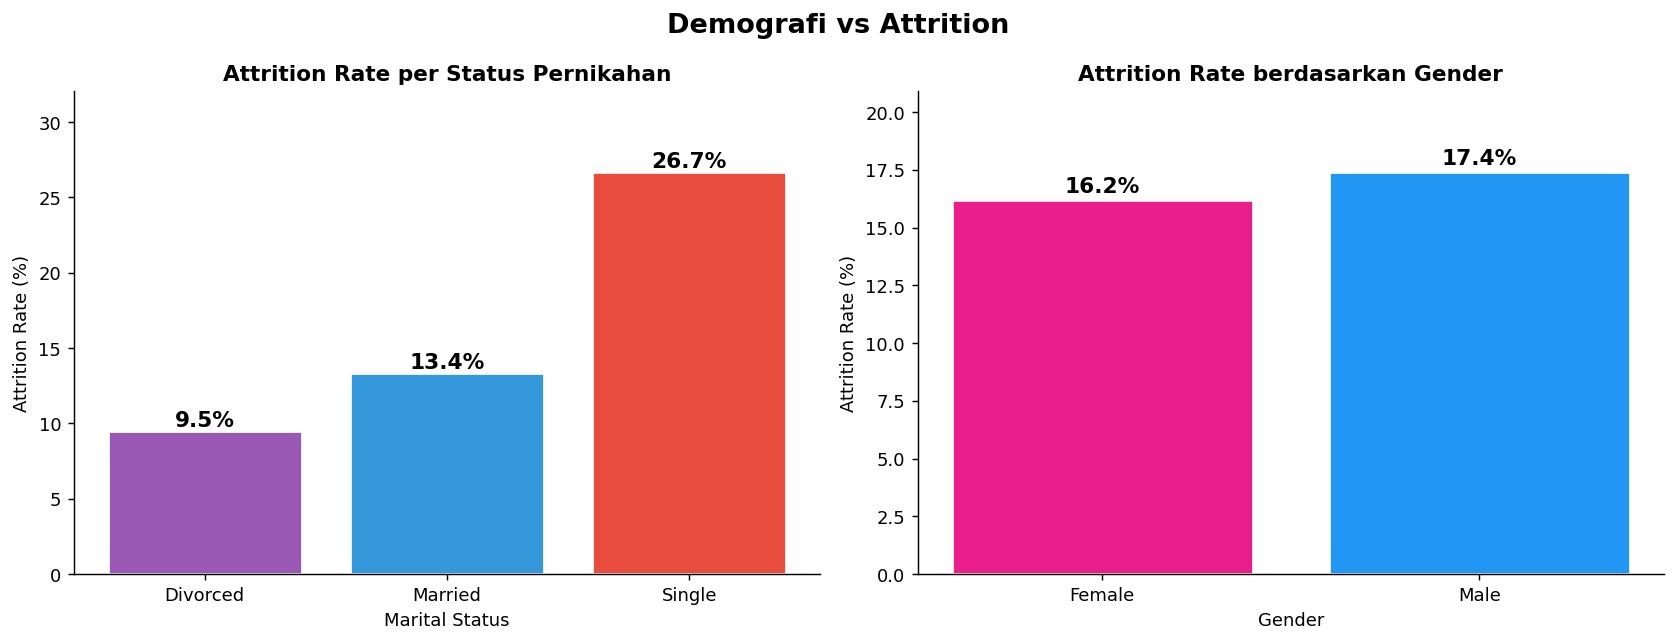


Insight Kunci:
Divorced: Attrition Rate = 9.5%
Married: Attrition Rate = 13.4%
Single: Attrition Rate = 26.7%


In [15]:
# ── EDA 8: Marital Status & Gender vs Attrition ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Demografi vs Attrition', fontsize=15, fontweight='bold')

# Marital Status
ms_rate = df_eda.groupby('MaritalStatus')['Attrition'].mean() * 100
bars = axes[0].bar(ms_rate.index, ms_rate.values,
                   color=['#9b59b6', '#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, ms_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Attrition Rate per Status Pernikahan', fontweight='bold')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, max(ms_rate.values) * 1.2)
sns.despine(ax=axes[0])

# Gender
gen_rate = df_eda.groupby('Gender')['Attrition'].mean() * 100
bars = axes[1].bar(gen_rate.index, gen_rate.values,
                   color=['#e91e8c', '#2196f3'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, gen_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Attrition Rate berdasarkan Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(gen_rate.values) * 1.2)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print("\nInsight Kunci:")
for ms, r in ms_rate.items():
    print(f"{ms}: Attrition Rate = {r:.1f}%")

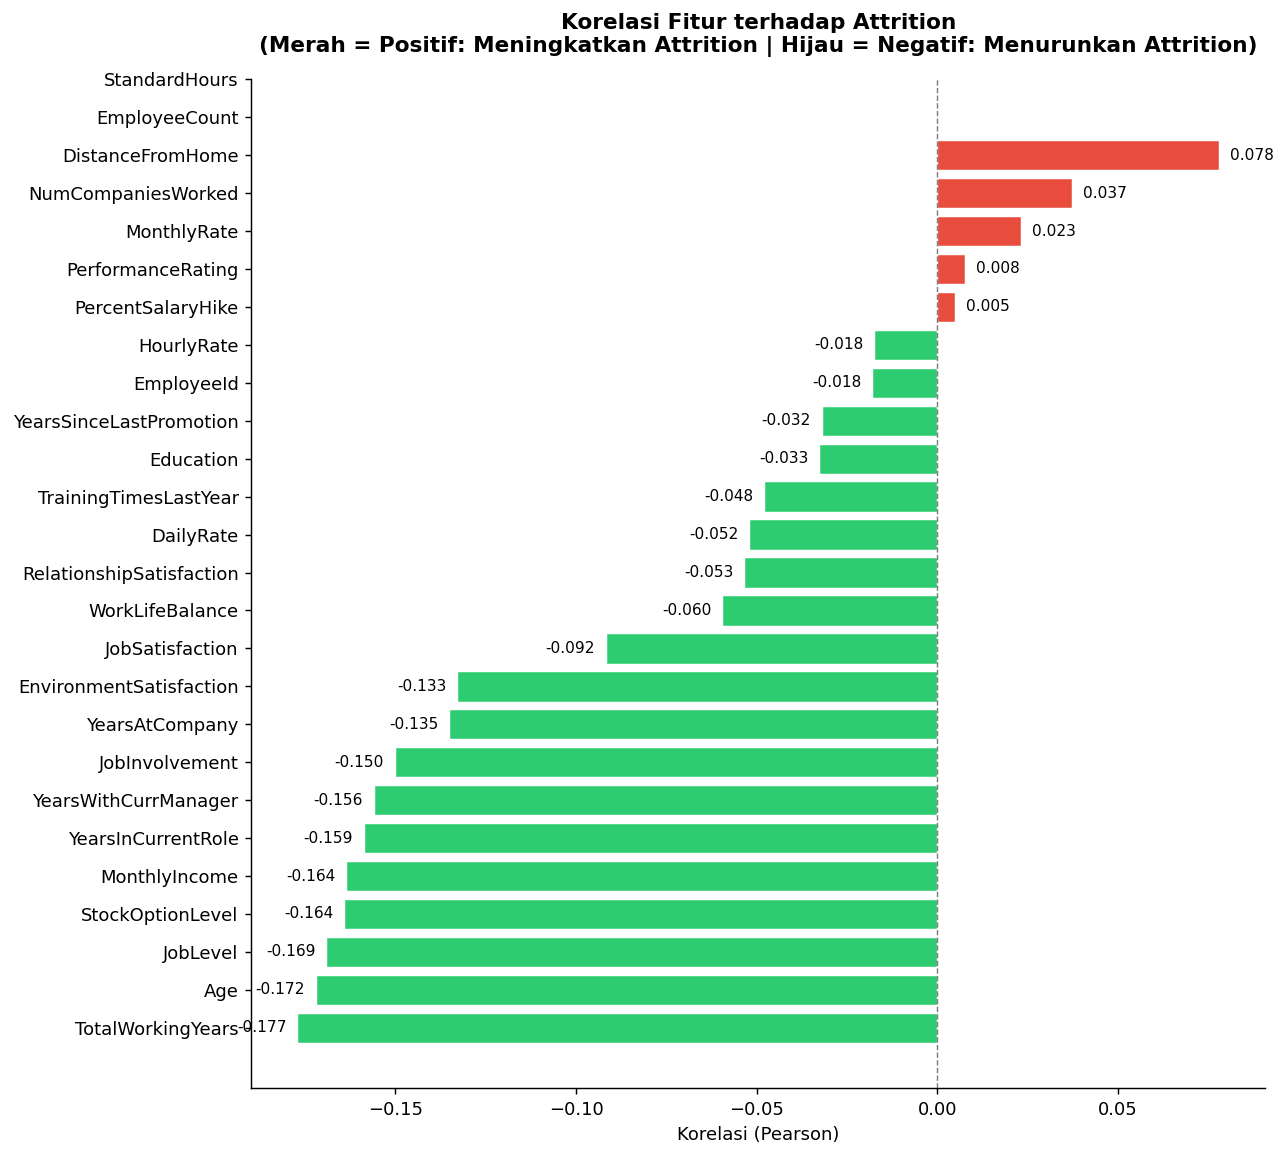


Top 5 Faktor Positif (meningkatkan attrition):
   DistanceFromHome: 0.078
   NumCompaniesWorked: 0.037
   MonthlyRate: 0.023
   PerformanceRating: 0.008
   PercentSalaryHike: 0.005

Top 5 Faktor Negatif (menurunkan attrition):
   TotalWorkingYears: -0.177
   Age: -0.172
   JobLevel: -0.169
   StockOptionLevel: -0.164
   MonthlyIncome: -0.164


In [16]:
# ── EDA 9: Korelasi terhadap Attrition ────────────────────────
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr_with_attrition = df_eda[numeric_cols].corr()['Attrition'].drop('Attrition').sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors_corr = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_attrition.values]
bars = ax.barh(range(len(corr_with_attrition)), corr_with_attrition.values, color=colors_corr,
               edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(corr_with_attrition)))
ax.set_yticklabels(corr_with_attrition.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Korelasi Fitur terhadap Attrition\n(Merah = Positif: Meningkatkan Attrition | Hijau = Negatif: Menurunkan Attrition)',
             fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Korelasi (Pearson)')
for bar, val in zip(bars, corr_with_attrition.values):
    ax.text(val + (0.003 if val >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("\nTop 5 Faktor Positif (meningkatkan attrition):")
top5_pos = corr_with_attrition.sort_values(ascending=False).head(5)
for col, val in top5_pos.items():
    print(f"   {col}: {val:.3f}")

print("\nTop 5 Faktor Negatif (menurunkan attrition):")
top5_neg = corr_with_attrition.sort_values().head(5)
for col, val in top5_neg.items():
    print(f"   {col}: {val:.3f}")


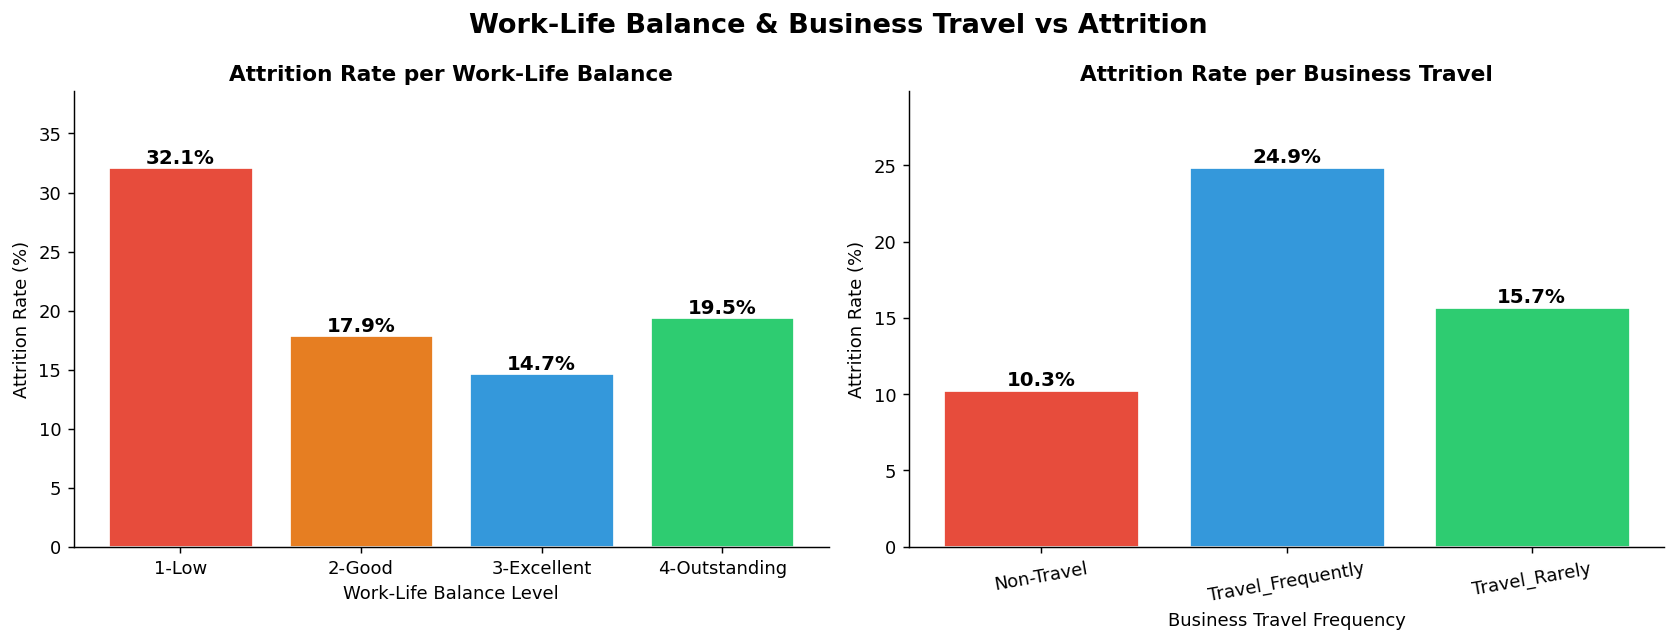

In [17]:
# ── EDA 10: Work-Life Balance & Business Travel vs Attrition ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Work-Life Balance & Business Travel vs Attrition', fontsize=15, fontweight='bold')

# Work-Life Balance
wlb_rate = df_eda.groupby('WorkLifeBalance')['Attrition'].mean() * 100
wlb_labels = {1: '1-Low', 2: '2-Good', 3: '3-Excellent', 4: '4-Outstanding'}
bars = axes[0].bar([wlb_labels[k] for k in wlb_rate.index], wlb_rate.values,
                   color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, wlb_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Attrition Rate per Work-Life Balance', fontweight='bold')
axes[0].set_xlabel('Work-Life Balance Level')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, max(wlb_rate.values) * 1.2)
sns.despine(ax=axes[0])

# Business Travel
bt_rate = df_eda.groupby('BusinessTravel')['Attrition'].mean() * 100
bars = axes[1].bar(bt_rate.index, bt_rate.values,
                   color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, bt_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Attrition Rate per Business Travel', fontweight='bold')
axes[1].set_xlabel('Business Travel Frequency')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(bt_rate.values) * 1.2)
axes[1].tick_params(axis='x', rotation=10)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


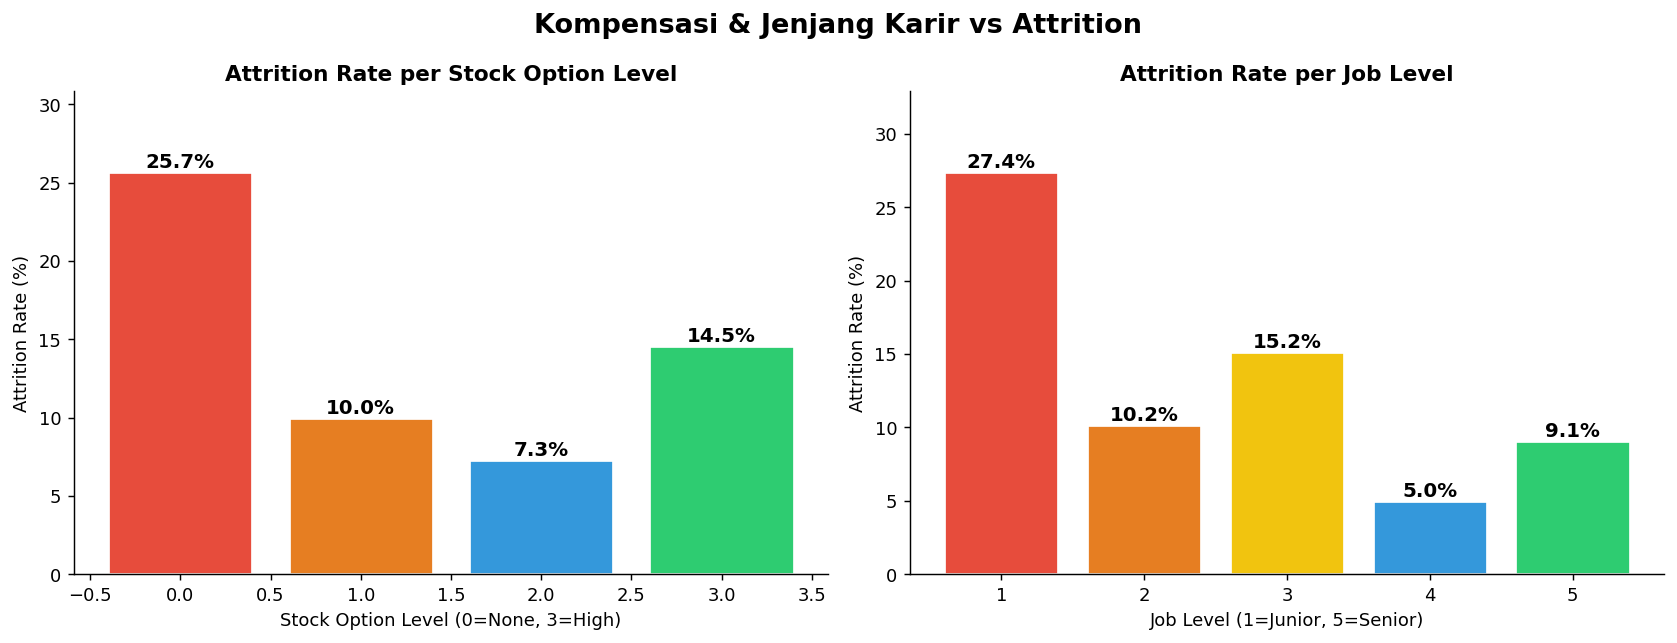

In [18]:
# ── EDA 11: Stock Option Level & Job Level vs Attrition ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Kompensasi & Jenjang Karir vs Attrition', fontsize=15, fontweight='bold')

# Stock Option
so_rate = df_eda.groupby('StockOptionLevel')['Attrition'].mean() * 100
bars = axes[0].bar(so_rate.index, so_rate.values,
                   color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, so_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Attrition Rate per Stock Option Level', fontweight='bold')
axes[0].set_xlabel('Stock Option Level (0=None, 3=High)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, max(so_rate.values) * 1.2)
sns.despine(ax=axes[0])

# Job Level
jl_rate = df_eda.groupby('JobLevel')['Attrition'].mean() * 100
bars = axes[1].bar(jl_rate.index, jl_rate.values,
                   color=['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#2ecc71'],
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, jl_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Attrition Rate per Job Level', fontweight='bold')
axes[1].set_xlabel('Job Level (1=Junior, 5=Senior)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, max(jl_rate.values) * 1.2)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


## Modeling (XGBoost)

In [19]:
# ── Training XGBoost ──────────────────────────────────────────
from xgboost import XGBClassifier

print("=" * 55)
print("XGBOOST CLASSIFIER")
print("=" * 55)

# Hitung scale_pos_weight untuk handle imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.6,
    min_child_weight=10,
    gamma=1,              # minimum loss reduction
    reg_alpha=0.5,        # L1 regularisasi
    reg_lambda=2.0,       # L2 regularisasi
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("Model berhasil ditraining!")
print(f"Fitur          : {X_train.shape[1]}")
print(f"Estimators     : {xgb_model.n_estimators}")
print(f"Max Depth      : {xgb_model.max_depth}")
print(f"Learning Rate  : {xgb_model.learning_rate}")
print(f"Scale Pos Weight: {scale_pos:.2f} (menangani imbalance)")

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"\n5-Fold CV ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

XGBOOST CLASSIFIER
Model berhasil ditraining!
Fitur          : 30
Estimators     : 500
Max Depth      : 3
Learning Rate  : 0.01
Scale Pos Weight: 4.92 (menangani imbalance)

5-Fold CV ROC-AUC: nan ± nan


## Evaluation

> **Mengapa Recall penting?**  
> Dalam konteks HR attrition, **False Negative** (karyawan berisiko tidak terdeteksi) lebih mahal daripada **False Positive** (karyawan aman dianggap berisiko). Oleh karena itu, **Recall** menjadi metrik prioritas.


In [20]:
# ── Prediction & Metrics ──────────────────────────────────────
y_prob = xgb_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.4).astype(int)

print("=" * 55)
print("EVALUATION METRICS (XGBoost, threshold=0.29)")
print("=" * 55)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}  ← PRIORITAS")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

EVALUATION METRICS (XGBoost, threshold=0.29)
Accuracy : 0.7264
Precision: 0.3553
Recall   : 0.7500  ← PRIORITAS
F1-Score : 0.4821
ROC-AUC  : 0.8054

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.93      0.72      0.81       176
   Attrition       0.36      0.75      0.48        36

    accuracy                           0.73       212
   macro avg       0.64      0.74      0.65       212
weighted avg       0.84      0.73      0.76       212



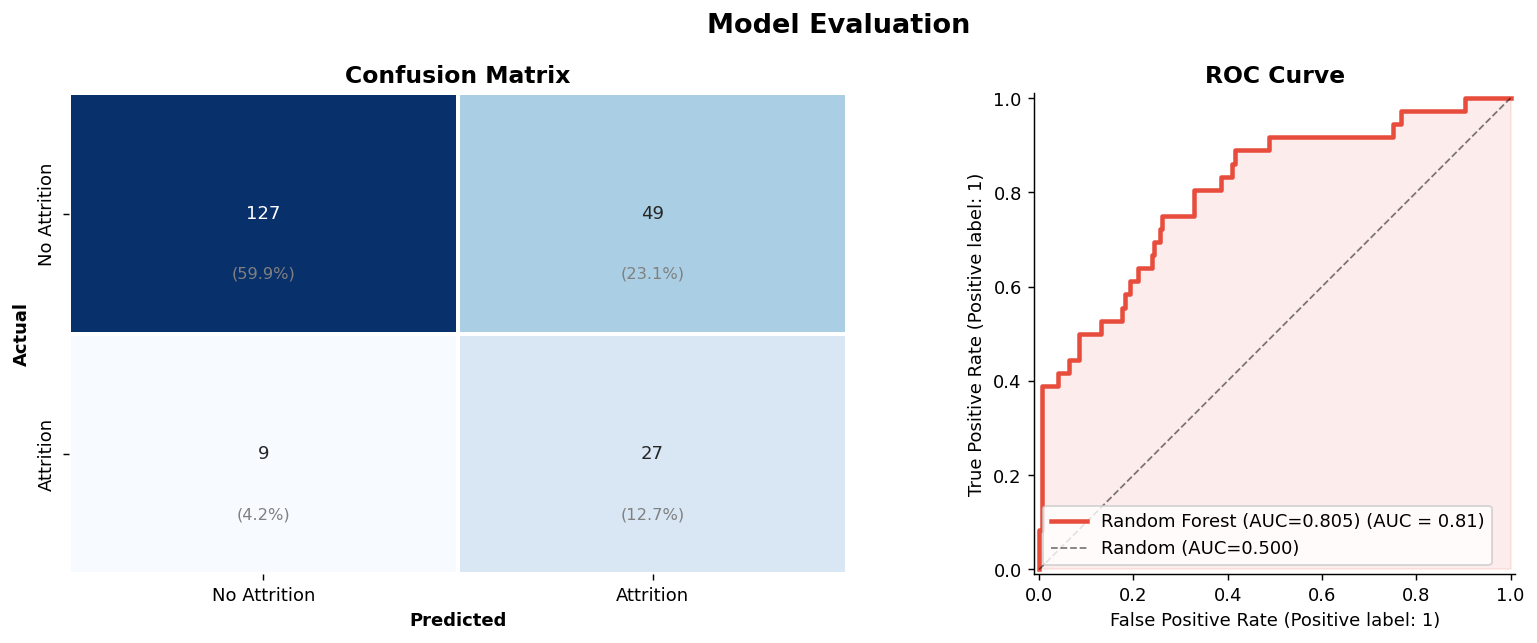


INTERPRETASI MODEL:
   ROC-AUC = 0.805 → Model sangat baik (≥0.80)
   Recall  = 0.750 → Baik dalam mendeteksi karyawan berisiko

Dari Confusion Matrix:
   TP=27 (benar deteksi attrition), FN=9 (miss karyawan berisiko)
   TN=127 (benar deteksi aman), FP=49 (false alarm)


In [21]:
# ── Visualization: Confusion Matrix & ROC Curve ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'],
            linewidths=2, linecolor='white', cbar=False)

# Add percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        axes[0].text(j + 0.5, i + 0.75, f'({pct:.1f}%)',
                     ha='center', va='center', fontsize=9, color='gray')

axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_xlabel('Predicted', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  color='#e74c3c', linewidth=2.5,
                                  name=f'Random Forest (AUC={roc_auc_score(y_test, y_prob):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.500)')
axes[1].fill_between(axes[1].lines[0].get_xdata(), axes[1].lines[0].get_ydata(),
                      alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# Interpretation
roc = roc_auc_score(y_test, y_prob)
rec = recall_score(y_test, y_pred)
print(f"\nINTERPRETASI MODEL:")
print(f"   ROC-AUC = {roc:.3f} → Model {'sangat baik (≥0.80)' if roc >= 0.80 else 'perlu peningkatan'}")
print(f"   Recall  = {rec:.3f} → {'Baik' if rec >= 0.70 else 'Perlu penyesuaian threshold'} dalam mendeteksi karyawan berisiko")
print(f"\nDari Confusion Matrix:")
print(f"   TP={cm[1,1]} (benar deteksi attrition), FN={cm[1,0]} (miss karyawan berisiko)")
print(f"   TN={cm[0,0]} (benar deteksi aman), FP={cm[0,1]} (false alarm)")


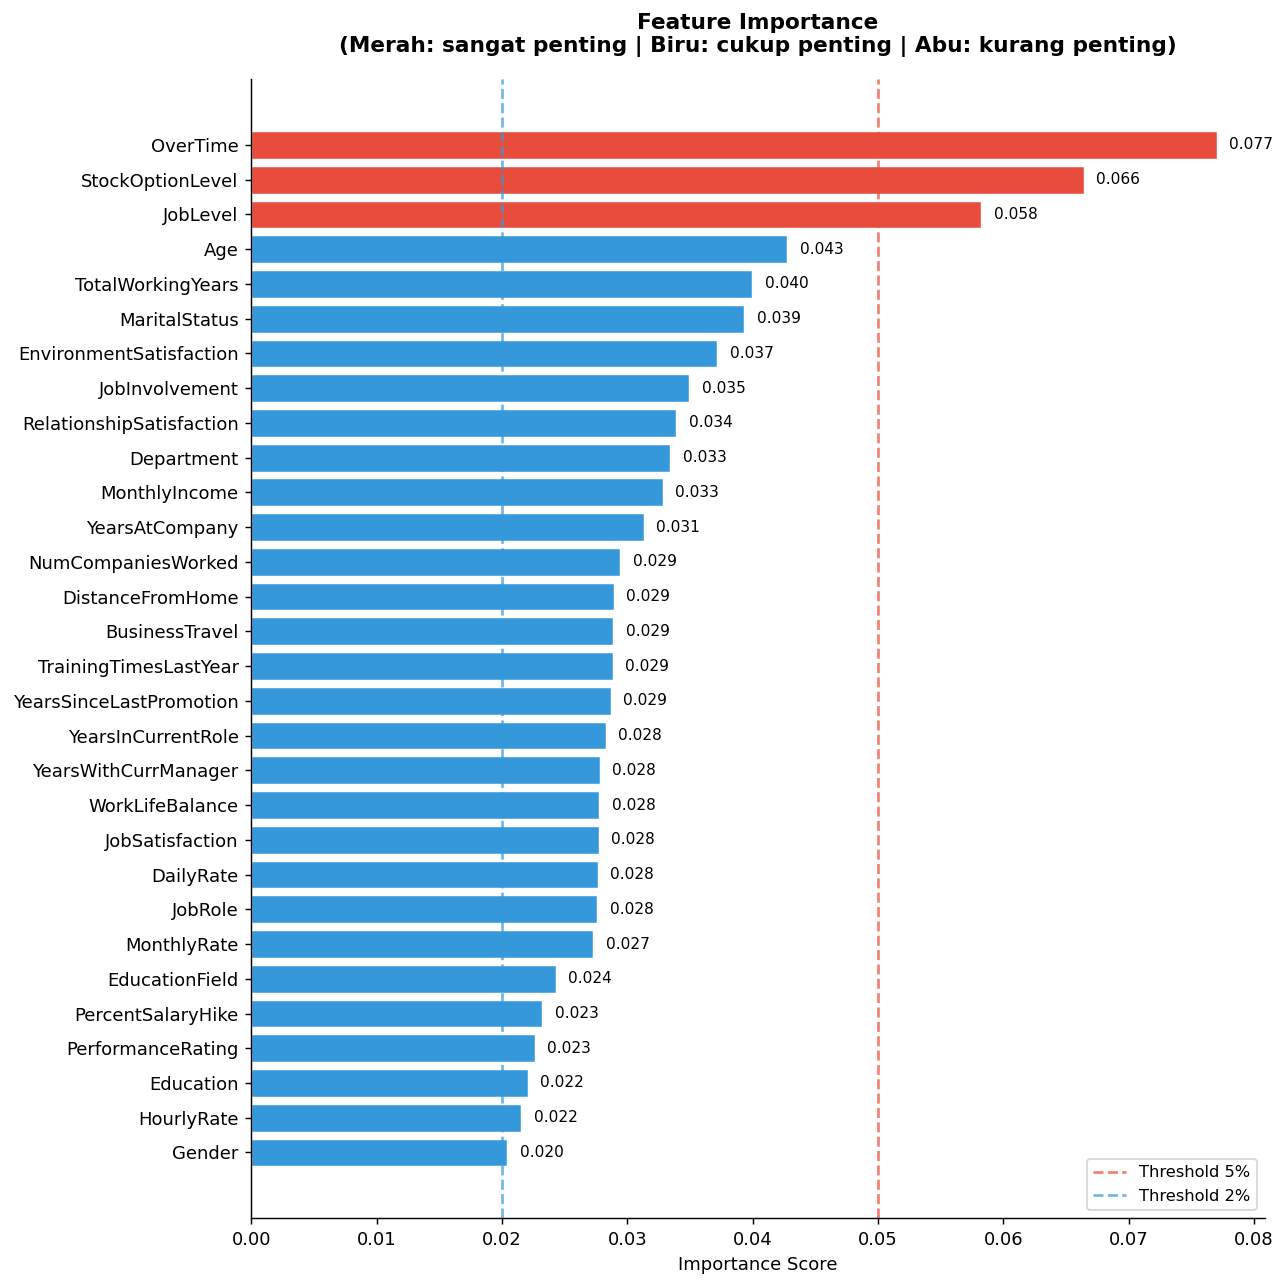


Top 10 Fitur Terpenting:
    1. OverTime                       0.0770
    2. StockOptionLevel               0.0664
    3. JobLevel                       0.0582
    4. Age                            0.0428
    5. TotalWorkingYears              0.0400
    6. MaritalStatus                  0.0393
    7. EnvironmentSatisfaction        0.0372
    8. JobInvolvement                 0.0349
    9. RelationshipSatisfaction       0.0339
   10. Department                     0.0334


In [22]:
# ── Feature Importance ────────────────────────────────────────
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors_fi = ['#e74c3c' if imp > 0.05 else '#3498db' if imp > 0.02 else '#95a5a6'
             for imp in feat_imp['Importance']]
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_fi,
               edgecolor='white', linewidth=0.8)
ax.axvline(0.05, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5, label='Threshold 5%')
ax.axvline(0.02, color='#3498db', linestyle='--', alpha=0.7, linewidth=1.5, label='Threshold 2%')
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8.5)
ax.set_title('Feature Importance\n(Merah: sangat penting | Biru: cukup penting | Abu: kurang penting)',
             fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Importance Score')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Terpenting:")
top10 = feat_imp.sort_values('Importance', ascending=False).head(10)
for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(f"   {i:>2}. {row['Feature']:<30} {row['Importance']:.4f}")


## Simpan Model

In [23]:
# ── Save Model ────────────────────────────────────────────────
import os
os.makedirs('model', exist_ok=True)

# Save model
joblib.dump(xgb_model, 'model/model.pkl')

# Save feature names (penting untuk inference)
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'model/feature_names.pkl')

# Save label encoders
joblib.dump(label_maps, 'model/label_maps.pkl')

print("Model tersimpan!")

# Verify load
loaded = joblib.load('model/model.pkl')
test_pred = loaded.predict(X_test[:3])
print(f"\nVerifikasi load model berhasil — contoh prediksi: {test_pred.tolist()}")


Model tersimpan!

Verifikasi load model berhasil — contoh prediksi: [0, 0, 0]
